In [18]:
import pandas as pd
import json
from globals import BASE_DIR, available_datasets, top_k_eval, valid_popularity, recommendation_dirpart
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import math
from postprocess_baseline_top_k import dataset_metadata
from evaluation_metrics import ndcg, calculate_arp_poplift, evaluation_user_group_means, jensen_shannon
import pingouin as pg


dataset = "yelp" # perform for each dataset individually

len(available_datasets) # make sure the available datasets are correct since this affects the Bonferroni correction of the t-tests

1

In [19]:
def process_top_k_json(input_file, output_file, k=10):
    """
    Process top-k recommendations from a JSON file, keeping only the item IDs for each user.
    """
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    try:
        with open(input_file, "r") as infile:
            data = json.load(infile)

        top_k_result = {}
        for user_id, recommendations in data.items():
            if recommendations and isinstance(recommendations[0], dict):
                item_ids = recommendations[0]["item_id"][:k]
                top_k_result[user_id] = item_ids

        with open(output_file, "w") as outfile:
            json.dump(top_k_result, outfile, indent=4)
        print(f"Processed file saved to: {output_file}")
    
    except Exception as e:
        print(f"Error processing {input_file}: {e}")

In [20]:
def create_model_directories(dataset, data, base_dir, recommendation_dirpart):
    """
    Create output directories
    """
    model_directories = {}
    methods = ["baseline", "cp", "cp_min_js", "mmr", "geo", "borda", "schulze"]

    def recommender_dir_combiner(dataset, modelpart, method):
        return os.path.join(base_dir, f"{dataset}_dataset", recommendation_dirpart, modelpart, method, "top_k_recommendations.json")

    for result in data:
        model_name = result["model"]
        model_directories[model_name] = {}
        
        for method in methods:
            model_directories[model_name][method] = recommender_dir_combiner(dataset, result["directory"], method)
    
    return model_directories

def open_ground_truth_user_group(dataset, valid_popularity=valid_popularity):
    """Perform data splitting and user group creation."""

    train_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.train.inter"), sep="\t")
    test_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.test.inter"), sep="\t")
    valid_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.valid.inter"), sep="\t")

    print("Train data, test data and valid data shapes:")
    print(train_data.shape, test_data.shape, valid_data.shape)
    train_data = pd.concat([train_data, valid_data])
    user_group_dir = os.path.join(BASE_DIR, f"{dataset}_dataset", f"{dataset}_user_id_popularity.json")
    with open(user_group_dir) as f:
        user_groups = json.load(f)

    user_groups["HighPop"] = user_groups.pop("high")
    user_groups["LowPop"] = user_groups.pop("low")
    user_groups["MedPop"] = user_groups.pop("medium")



    checkin_df = train_data.copy()
    
    # Calculate item popularity
    value_counts = checkin_df["item_id:token"].value_counts().reset_index()
    value_counts.columns = ["item_id:token", "count"]
    value_counts[valid_popularity] = value_counts["count"] / len(value_counts)
    checkin_df = checkin_df.merge(
        value_counts[["item_id:token", valid_popularity]],
        on="item_id:token",
        how="left",
    )
    checkin_df.sort_values(by=valid_popularity, ascending=False, inplace=True)
    item_popularity = checkin_df.drop_duplicates(subset="item_id:token", keep="first")[
        ["item_id:token", valid_popularity]
    ]

    h_group = item_popularity.head(int(len(item_popularity) * 0.2))
    h_group["item_pop_group"] = "h"
    t_group = item_popularity.tail(int(len(item_popularity) * 0.2))
    t_group["item_pop_group"] = "t"
    m_group = item_popularity[
        ~item_popularity["item_id:token"].isin(h_group["item_id:token"]) &
        ~item_popularity["item_id:token"].isin(t_group["item_id:token"])
    ]
    m_group["item_pop_group"] = "m"

    item_popularity = pd.concat([h_group, m_group, t_group])
    item_popularity.sort_values(by=valid_popularity, inplace=True, ascending=False)

    upts = checkin_df.groupby("user_id:token")[valid_popularity].mean().reset_index()
    upts.columns = ["user_id:token", "upts"]
    return train_data, test_data, user_groups, item_popularity, upts


In [21]:
data = dataset_metadata(dataset, recommendation_dirpart)

In [22]:
data

[{'directory': 'yelp_sample-contextpoi-USG-Jan-22-2025_09-00-00',
  'dataset': 'yelp_sample',
  'model_type': 'contextpoi',
  'model': 'USG',
  'date': 'Jan-22-2025_09-00-00'},
 {'directory': 'yelp_sample-contextpoi-LORE-Jan-22-2025_09-00-00',
  'dataset': 'yelp_sample',
  'model_type': 'contextpoi',
  'model': 'LORE',
  'date': 'Jan-22-2025_09-00-00'},
 {'directory': 'yelp_sample-BPR-Jan-22-2025_15-15-41',
  'dataset': 'yelp_sample',
  'model_type': 'general',
  'model': 'BPR',
  'date': 'Jan-22-2025_15-15-41'}]

In [23]:
model_dirs = create_model_directories(dataset, data, BASE_DIR, recommendation_dirpart)

In [24]:
def unstack_recommendations(df):
    """Unstack the recommendations for each user into separate rows."""
    unstacked_df = df.explode(["item_id:token"]).reset_index(drop=True)
    return unstacked_df

In [25]:
def top_k_to_df(recommender_dir, top_k_eval=10):
    """ Fixed version that handles nested lists """
    with open(recommender_dir) as f:
        data = json.load(f)
    
    base_recommendations = []
    
    for user, items in data.items():
        # FIX: Check if items is nested [[...]]
        if isinstance(items, list) and len(items) > 0 and isinstance(items[0], list):
            # Flatten: items = [[...]] -> items = [...]
            items = items[0]
        
        # Now iterate through individual items
        for item in items:
            base_recommendations.append({
                "user_id:token": user,
                "item_id:token": item
            })
    
    base_df = pd.DataFrame(base_recommendations)
    base_df = unstack_recommendations(base_df)
    df = base_df.groupby("user_id:token").head(top_k_eval)
    
    return df

In [26]:
train_data, test_data, user_groups, item_popularity, upts = open_ground_truth_user_group(dataset)
user_groups["All"] = user_groups["HighPop"] + user_groups["MedPop"] + user_groups["LowPop"]

Train data, test data and valid data shapes:
(22282, 3) (7633, 3) (5373, 3)


/tmp/ipykernel_4272/1417446135.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h_group["item_pop_group"] = "h"
/tmp/ipykernel_4272/1417446135.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_group["item_pop_group"] = "t"
/tmp/ipykernel_4272/1417446135.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

In [27]:
test_data

,user_id:token,item_id:token,checkin_count:float
0,0_x,532_x,1
1,0_x,1872_x,1
2,0_x,2269_x,1
3,0_x,2619_x,1
4,0_x,3689_x,1
...,...,...,...
7628,9_x,979_x,1
7629,9_x,65_x,1
7630,9_x,2087_x,1
7631,9_x,4440_x,1


In [28]:
def create_pop_distributions(data):
    """Create a DataFrame with the distribution of item popularity for different user groups."""
    data = data.merge(item_popularity, on="item_id:token", how="left")
    g1 = data.loc[data["user_id:token"].isin(user_groups["HighPop"])].value_counts("item_pop_group", normalize=True).rename("g1")
    g2 = data.loc[data["user_id:token"].isin(user_groups["MedPop"])].value_counts("item_pop_group", normalize=True).rename("g2")
    g3 = data.loc[data["user_id:token"].isin(user_groups["LowPop"])].value_counts("item_pop_group", normalize=True).rename("g3")
    all = data.value_counts("item_pop_group", normalize=True).rename("all")
    distr_df = pd.DataFrame([g1, g2, g3, all]).fillna(0)
    distr_df.rename(index={"g1":"HighPop", "g2":"MedPop", "g3":"LowPop", "all":"All"}, inplace=True)
    return distr_df


ground_truth_distr = create_pop_distributions(train_data)

In [29]:
ground_truth_distr

item_pop_group,h,m,t
HighPop,0.710990,0.266569,0.022441
MedPop,0.442081,0.499832,0.058087
LowPop,0.290590,0.614717,0.094693
All,0.460676,0.480673,0.058651


In [30]:
def preprocess_distr(distr_df):
    """Preprocess the distribution DataFrame for plotting."""
    #distr_df.rename(index={"g1":"HighPop", "g2":"MedPop", "g3":"LowPop", "all":"All"}, inplace=True) # COMMENT IN FOR CALCULATING RESULTS, COMMENT OUT FOR PLOTTING
    data = distr_df.to_dict()
    result = []
    user_groups = data["h"].keys()

    for group in user_groups:
        h_value = data.get("h", {}).get(group, 0)
        m_value = data.get("m", {}).get(group, 0)
        t_value = data.get("t", {}).get(group, 0)
        
        result.append({
            "user_group": group,
            "h_ratio": h_value,
            "m_ratio": m_value,
            "t_ratio": t_value
        })

    return result


In [31]:
# Function for plotting popularity distribution (no legend inside this function)
def plot_popularity_distribution(ax, distr_df, label):
    """ Plot the popularity distribution of items for different user groups."""
    desired_order = ["LowPop", "MedPop", "HighPop", "All"]
    distr_df = distr_df.reindex(desired_order)
    colors = plt.cm.viridis([0.1, 0.5, 0.9])
    bars = distr_df.plot(kind="bar", stacked=True, ax=ax, color=colors, legend=False, edgecolor="black", linewidth=0, width=0.6)
    if label is not None:
        ax.set_title(f"{label}", fontsize=10)
    ax.set_xlabel("User Groups")
    return distr_df

def plot_line_chart(results, model_name, ax, metric):
    """
    Plot scores (nDCG, ARP, PopLift) as line plots for each user group, comparing methods.
    """
    methods = ["baseline", "cp", "cp_min_js", "mmr", "geo", "borda", "schulze"]
    user_groups = ["HighPop", "MedPop", "LowPop", "All"]
    group_labels = ["HighPop", "MedPop", "LowPop", "All"]

    metric_values = {
        method: [results[model_name][method][group][f"{metric}"] for group in user_groups]
        for method in methods
    }

    metric_transposed = list(zip(*metric_values.values()))  # Group-wise scores across methods

    # Plot each user group"s metric scores as a line plot
    colors = plt.cm.viridis([0.1, 0.5, 0.9, 0.3])
    for idx, group_label in enumerate(group_labels):
        ax.plot(methods, metric_transposed[idx], marker="o", label=group_label, color=colors[idx])

    ax.set_ylabel(f"{metric.upper()} Score", fontsize=12)
    ax.grid(True)
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)




In [32]:
def calculate_t_test_between_user_groups(group_scores):
    """ Calculate t-test for two-sample t-test between low and high groups. 
    Source t-test: https://www.geeksforgeeks.org/how-to-conduct-a-two-sample-t-test-in-python/"""
    
    ttest = {}
    # Conducting two-sample ttest
    result_low_high = pg.ttest(list(group_scores["LowPop"].values()), 
                    list(group_scores["HighPop"].values()),
                    correction=True)
    
    result_low_med = pg.ttest(list(group_scores["LowPop"].values()), 
                    list(group_scores["MedPop"].values()),
                    correction=True)
    
    ttest["low_high"] = float(result_low_high["p-val"])
    ttest["low_medium"] = float(result_low_med["p-val"])

    return ttest


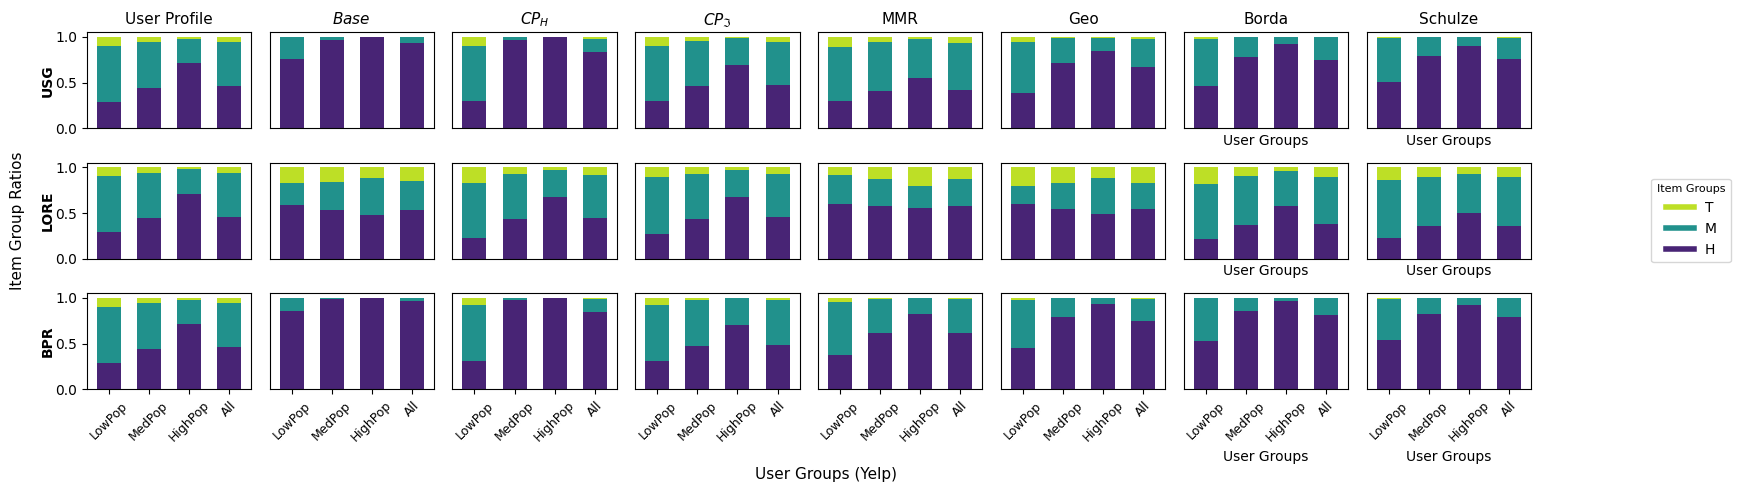

In [33]:
""" Looping through the models and methods to plot the popularity distribution """
fig, axs = plt.subplots(3, 8, figsize=(16, 5.5))  # 3 models x 4 methods
method_names_for_title = ["$Base$", "$CP_H$", "$CP_\Im$", "MMR", "Geo", "Borda", "Schulze"]

# model_dirs_plot = copy.deepcopy(model_dirs)
filtered_models = [
    (model_name, methods)
    for model_name, methods in model_dirs.items()
    if model_name not in ["SimpleX", "plurality", "borda"]
]

for i, (model_name, methods) in enumerate(filtered_models):
    # print(model_name)   
    ax = axs[i, 0]
    plot_popularity_distribution(ax, ground_truth_distr, None)  # no title here
    if i == 0:
        ax.set_title("User Profile", fontsize=11)

    for j, (method_name, json_file) in enumerate(methods.items()):
        # print(method_name, json_file)
        df = top_k_to_df(json_file)
        distr_df = create_pop_distributions(df)

        ax = axs[i, j + 1]
        plot_popularity_distribution(ax, distr_df, None)  # no title here
        if i == 0:
            ax.set_title(method_names_for_title[j], fontsize=11)


    axs[i, 0].set_ylabel(model_name, fontsize=10, weight="bold", labelpad=0)

    if i == 5:
                for k in range(8):
                    axs[i, k].set_xticks(range(8))
                    axs[i, k].set_xlabel("User Groups")
    else:
        for k in range(8):
            axs[i, k].set_xlabel("")

for ax in axs[-1, :]:
    ax.set_xticks(range(4))
    ax.set_xticklabels(["LowPop", "MedPop", "HighPop", "All"], rotation=45, fontsize=9)

for row in axs[:-1, :]:
    for ax in row:
        ax.set_xticks([])

for row in axs:
    for ax in row[1:]:
        ax.set_yticks([])


fig.text(0.55, 0.03, f"User Groups ({dataset.capitalize()})", ha="center", fontsize=11)
fig.text(0.04, 0.5, "Item Group Ratios", va="center", rotation="vertical", fontsize=11)

handles = [plt.Line2D([0], [0], color=color, lw=4) for color in plt.cm.viridis([0.9, 0.5, 0.1])]
labels = ["T", "M", "H"]


fig.legend(handles, labels, title="Item Groups", loc="center right", bbox_to_anchor=(1.12, 0.5), ncol=1, title_fontsize=8)
#fig.suptitle(f"Popularity Distribution for {dataset.capitalize()} Dataset", fontsize=12, weight="bold", y=0.87, x=0.57)
plt.tight_layout(rect=[0.05, 0.03, 1, 0.91])
plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", "popularity_distribution_paper.png"), bbox_inches="tight")


In [34]:
""" Looping through the models and methods to store and process the results """
group_scores_ndcg = {}
group_scores_arp = {}
group_scores_poplift = {}
results = {}
ttest_results = {}

distr_dict_ground_truth = preprocess_distr(ground_truth_distr)

for i, (model_name, methods) in enumerate(model_dirs.items()):
    if model_name not in ["SimpleX"]:
        results[model_name] = {}
        ttest_results[model_name] = {}

        group_scores_ndcg[model_name] = {}
        group_scores_arp[model_name] = {}
        group_scores_poplift[model_name] = {}

        for j, (method_name, json_file) in enumerate(methods.items()):

            ttest_results[model_name][method_name] = {}
  
            df = top_k_to_df(json_file)

            # print(f"\n=== {model_name} / {method_name} ===")
            # print(f"df user_id type: {df['user_id:token'].dtype}, sample: {df['user_id:token'].iloc[:3].tolist()}")
            # print(f"test_data user_id type: {test_data['user_id:token'].dtype}, sample: {test_data['user_id:token'].iloc[:3].tolist()}")
            # rec_items = set(df["item_id:token"].unique())
            # test_items = set(test_data["item_id:token"].unique())
            # print(f"Rec items: {len(rec_items)}, Test items: {len(test_items)}, Overlap: {len(rec_items & test_items)}")
            # # Check overlap
            # rec_users = set(df["user_id:token"].unique())
            # test_users = set(test_data["user_id:token"].unique())
            # print(f"Rec users: {len(rec_users)}, Test users: {len(test_users)}, Overlap: {len(rec_users & test_users)}")

            ndcg_scores = ndcg(df=df, test_data=test_data, top_k_eval=top_k_eval)
            df_with_item_pop = df.merge(item_popularity, on="item_id:token", how="left")
            arp_scores, poplift_scores = calculate_arp_poplift(df_with_item_pop, item_popularity, upts, valid_popularity)
            distr_df = create_pop_distributions(df)
            distr_dict_recs = preprocess_distr(distr_df)

            


            jsd_group = {}
            for group_gt, group_recs in zip(distr_dict_ground_truth, distr_dict_recs):
                jsd_group[group_gt["user_group"]] = jensen_shannon(group_gt, group_recs)

            group_eval, group_ndcg_scores, group_arp_scores, group_poplift_scores = evaluation_user_group_means(ndcg_scores, arp_scores, poplift_scores, user_groups, df)

            group_scores_ndcg[model_name][method_name] = group_ndcg_scores
            group_scores_arp[model_name][method_name] = group_arp_scores
            group_scores_poplift[model_name][method_name] = group_poplift_scores

            # ttests between low and high / low and medium to check whether LowPop users are disadvantaged
            # ttest_results[model_name][method_name]["ndcg"] = calculate_t_test_between_user_groups(group_ndcg_scores)
            # ttest_results[model_name][method_name]["arp"] = calculate_t_test_between_user_groups(group_arp_scores)
            # ttest_results[model_name][method_name]["poplift"] = calculate_t_test_between_user_groups(group_poplift_scores)
        
            for group_name, jsd_value in jsd_group.items():
                if group_name in group_eval:
                    group_eval[group_name]["js"] = jsd_value
                else:
                    # In case the group exists in jsd_group but not in group_eval
                    group_eval[group_name] = {"js": jsd_value}

            results[model_name][method_name] = group_eval

In [35]:
def format_raw_results(general_results):
    rows = []
    for model, methods in general_results.items():
        for method, groups in methods.items():
            for group, metrics in groups.items():
                row = {"model": model, "method": method, "group": group}
                row.update({k: round(v, 4) for k, v in metrics.items()})
                rows.append(row)
    
    return pd.DataFrame(rows)

df_results_raw = format_raw_results(results)
df_results_single_agent = df_results_raw.loc[df_results_raw["method"].isin(["baseline", "cp", "cp_min_js", "geo", "mmr"])]
df_results_aggregate = df_results_raw.loc[df_results_raw["method"].isin(["borda", "schulze"])]
df_results_raw.to_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "evaluation_results_raw.csv"), index=False)
df_results_single_agent.to_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "evaluation_results_single_agents.csv"), index=False)
df_results_aggregate.to_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "evaluation_results_aggregate.csv"), index=False)

In [36]:
df_results_aggregate

,model,method,group,ndcg,arp,poplift,gini,js
20,USG,borda,HighPop,0.0593,0.0065,0.4305,0.6710,0.0557
21,USG,borda,LowPop,0.0243,0.0026,0.7549,0.4979,0.0377
22,USG,borda,MedPop,0.0310,0.0055,1.3601,0.6839,0.0984
23,USG,borda,All,0.0353,0.0051,1.0531,0.6997,0.0698
24,USG,schulze,HighPop,0.0668,0.0077,0.6910,0.7156,0.0468
25,USG,schulze,LowPop,0.0288,0.0028,0.8853,0.5634,0.0488
26,USG,schulze,MedPop,0.0324,0.0059,1.5036,0.7432,0.1033
27,USG,schulze,All,0.0386,0.0056,1.2174,0.7556,0.0746
48,LORE,borda,HighPop,0.0215,0.0028,-0.3926,0.5241,0.0153
49,LORE,borda,LowPop,0.0515,0.0014,-0.0626,0.4458,0.0143


In [37]:
df_results_single_agent.loc[df_results_single_agent["method"] == "baseline"]

,model,method,group,ndcg,arp,poplift,gini,js
0,USG,baseline,HighPop,0.0827,0.0094,1.0661,0.6638,0.1605
1,USG,baseline,LowPop,0.0276,0.0033,1.3230,0.5723,0.1819
2,USG,baseline,MedPop,0.0397,0.0075,2.2118,0.7626,0.2842
3,USG,baseline,All,0.0459,0.0070,1.8049,0.7777,0.2158
28,LORE,baseline,HighPop,0.0180,0.0024,-0.4764,0.4700,0.0769
29,LORE,baseline,LowPop,0.0563,0.0014,-0.0203,0.4117,0.0114
30,LORE,baseline,MedPop,0.0272,0.0019,-0.1798,0.4141,0.0253
31,LORE,baseline,All,0.0312,0.0019,-0.2072,0.4505,0.0263
56,BPR,baseline,HighPop,0.0800,0.0093,1.0542,0.6515,0.1591
57,BPR,baseline,LowPop,0.0221,0.0040,1.7702,0.6374,0.2660


In [38]:
df_results_raw

,model,method,group,ndcg,arp,poplift,gini,js
0,USG,baseline,HighPop,0.0827,0.0094,1.0661,0.6638,0.1605
1,USG,baseline,LowPop,0.0276,0.0033,1.3230,0.5723,0.1819
2,USG,baseline,MedPop,0.0397,0.0075,2.2118,0.7626,0.2842
3,USG,baseline,All,0.0459,0.0070,1.8049,0.7777,0.2158
4,USG,cp,HighPop,0.0827,0.0093,1.0605,0.6849,0.1445
...,...,...,...,...,...,...,...,...
79,BPR,borda,All,0.0332,0.0055,1.2321,0.7305,0.1119
80,BPR,schulze,HighPop,0.0674,0.0077,0.6889,0.6874,0.0618
81,BPR,schulze,LowPop,0.0192,0.0030,1.0375,0.6290,0.0678
82,BPR,schulze,MedPop,0.0275,0.0060,1.5811,0.7547,0.1250


In [39]:
def t_tests_rq1(metric_scores, model_1="BPR", other_models=["LORE", "USG"]):
    """ Perform t-tests between algorithms/methods to answer RQ1 (Compare Individual Effects of Context-Aware Recommendation and CP to general Baseline)
    Source t-test: https://www.geeksforgeeks.org/how-to-conduct-a-two-sample-t-test-in-python/"""

    ttest_results = {}

    # Compare to other models (LORE, USG)
    for other_model in other_models:
        ttest_results[other_model] = {}
        for group in ["HighPop", "MedPop", "LowPop", "All"]:
            baseline_1 = metric_scores.get(model_1, {}).get("baseline", {}).get(group, {})
            baseline_2 = metric_scores.get(other_model, {}).get("baseline", {}).get(group, {})

            common_users = set(baseline_1.keys()) & set(baseline_2.keys())

            if common_users:
                vals_1 = [baseline_1[u] for u in common_users]
                vals_2 = [baseline_2[u] for u in common_users]

                test = pg.ttest(vals_1, vals_2, paired=True, correction=True)
                delta = np.mean(vals_2) - np.mean(vals_1)

                ttest_results[other_model][group] = {
                    "p_val": float(test["p-val"].values[0]),
                    "delta": float(delta),
                }
            else:
                ttest_results[other_model][group] = {
                    "p_val": None,
                    "delta": None,
                }

    # Compare BPR baseline to its own variants
    for variant in ["cp", "cp_min_js", "mmr", "geo", "borda", "schulze"]:
        ttest_results[variant] = {}
        for group in ["HighPop", "MedPop", "LowPop", "All"]:
            baseline = metric_scores.get(model_1, {}).get("baseline", {}).get(group, {})
            variant_scores = metric_scores.get(model_1, {}).get(variant, {}).get(group, {})

            common_users = set(baseline.keys()) & set(variant_scores.keys())

            if common_users:
                vals_base = [baseline[u] for u in common_users]
                vals_variant = [variant_scores[u] for u in common_users]

                test = pg.ttest(vals_base, vals_variant, paired=True, correction=True)
                delta = np.mean(vals_variant) - np.mean(vals_base)

                ttest_results[variant][group] = {
                    "p_val": float(test["p-val"].values[0]),
                    "delta": float(delta),
                }
            else:
                ttest_results[variant][group] = {
                    "p_val": None,
                    "delta": None,
                }

    return ttest_results


In [40]:
def t_tests_rq2(group_scores):
    """Perform t-tests between algorithms/methods to answer RQ2."""
    ttest_results = {}

    # extend this list whenever a new reranker is added
    variants = ["cp", "cp_min_js", "mmr", "geo", "borda", "schulze"]

    for model_name, methods in group_scores.items():
        ttest_results[model_name] = {}

        for group in ["HighPop", "MedPop", "LowPop", "All"]:
            ttest_results[model_name][group] = {}

            def clean(d):
                return [float(v) for v in d.values() if isinstance(v, (float, int))]

            baseline_vals = clean(methods.get("baseline", {}).get(group, {}))

            for variant in variants:
                variant_vals = clean(methods.get(variant, {}).get(group, {}))

                if baseline_vals and variant_vals:
                    result = pg.ttest(baseline_vals, variant_vals, correction=True)
                    ttest_results[model_name][group][variant] = {
                        "p_val": float(result["p-val"].values[0]),
                        "delta": float(np.mean(variant_vals) - np.mean(baseline_vals)),
                    }
                else:
                    ttest_results[model_name][group][variant] = {
                        "p_val": None,
                        "delta": None,
                    }

    return ttest_results

In [41]:
ttest_rq1_ndcg = t_tests_rq1(group_scores_ndcg)
ttest_rq1_arp = t_tests_rq1(group_scores_arp)
ttest_rq1_poplift = t_tests_rq1(group_scores_poplift)

/home/aforster/dev/POI_RS_PopBias_Mitigation/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")


In [42]:
ttest_rq2_ndcg = t_tests_rq2(group_scores_ndcg)
ttest_rq2_arp = t_tests_rq2(group_scores_arp)
ttest_rq2_poplift = t_tests_rq2(group_scores_poplift)

/home/aforster/dev/POI_RS_PopBias_Mitigation/venv/lib/python3.11/site-packages/pingouin/bayesian.py:154: RuntimeWarning: overflow encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)
/home/aforster/dev/POI_RS_PopBias_Mitigation/venv/lib/python3.11/site-packages/pingouin/bayesian.py:154: RuntimeWarning: overflow encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)


In [43]:
def format_results_rq1_with_deltas(
    general_results,
    ttest_rq1_ndcg,
    ttest_rq1_arp,
    ttest_rq1_poplift
):
    
    """ Format the results to put them into a table inlcuding the Delta in Percent and +/-"""
    
    updated_results = copy.deepcopy(general_results["BPR"]["baseline"])

    ttest_dicts = {
        "ndcg": ttest_rq1_ndcg,
        "arp": ttest_rq1_arp,
        "poplift": ttest_rq1_poplift,
    }

    formatted_table = {}

    for group in updated_results:
        formatted_table[group] = {}
        for metric in ["ndcg", "arp", "poplift"]:
            base_val = updated_results[group][metric]
            base_str = f"{base_val:.4f}"
            row = {"BPR": base_str}

            for model in ["LORE", "USG"]:
                delta = ttest_dicts[metric][model][group]["delta"]
                p_val = ttest_dicts[metric][model][group]["p_val"]

                if base_val != 0:
                    percent_delta = (delta / base_val) * 100
                    delta_str = f"{percent_delta:+.2f}%"
                else:
                    delta_str = "N/A"

                # TO-DO: Not sure which is the right Bonferroni-correction
                if p_val is not None and p_val < 0.05/(16*len(available_datasets)):
                    delta_str += " **"

                row[model] = delta_str

            # Now compare BPR(cp) and BPR(cp_min_js) to BPR(baseline)
            for variant in ["cp", "cp_min_js", "mmr", "geo", "borda", "schulze"]:
                delta = ttest_dicts[metric][variant][group]["delta"]
                p_val = ttest_dicts[metric][variant][group]["p_val"]

                # Get the BPR baseline again for consistent comparison
                if base_val != 0:
                    percent_delta = (delta / base_val) * 100
                    delta_str = f"{percent_delta:+.2f}%"
                else:
                    delta_str = "N/A"

                if p_val is not None and p_val < 0.05/(16*len(available_datasets)):
                    delta_str += " **"

                row[variant] = delta_str

            formatted_table[group][metric] = row

    return formatted_table


In [44]:
rq1_results = format_results_rq1_with_deltas(results, ttest_rq1_ndcg, ttest_rq1_arp, ttest_rq1_poplift)

In [45]:
def format_results_rq2_with_deltas(
    general_results,
    ttest_rq2_ndcg,
    ttest_rq2_arp,
    ttest_rq2_poplift
):
    """ Format the results to put them into a table inlcuding the Delta in Percent and +/-"""
    updated_results = copy.deepcopy(general_results)
    ttest_dicts = {
        "ndcg": ttest_rq2_ndcg,
        "arp": ttest_rq2_arp,
        "poplift": ttest_rq2_poplift,
    }

    for model in general_results:
        for group in general_results[model]["baseline"]:
            for metric in ["ndcg", "arp", "poplift", "gini", "js"]:
                base_val = general_results[model]["baseline"][group][metric]
                # Format baseline value to 4 decimal places
                base_str = f"{base_val:.4f}"
                updated_results[model]["baseline"][group][metric] = base_str

            for method in ["cp", "cp_min_js", "mmr", "geo", "borda", "schulze"]:
                if method not in general_results[model]:
                    continue
                if group not in general_results[model][method]:
                    continue

                for metric in ["ndcg", "arp", "poplift"]:
                    cur_val = general_results[model][method][group][metric]
                    ttest_dict = ttest_dicts[metric]
                    try:
                        delta = ttest_dict[model][group][method]["delta"]
                        p_val = ttest_dict[model][group][method]["p_val"]
                    except KeyError:
                        continue

                    # Convert delta to percent relative to baseline
                    base_val = float(general_results[model]["baseline"][group][metric])
                    delta_percent = ((cur_val - base_val) / abs(base_val)) * 100 if base_val != 0 else 0
                    delta_str = f"{delta_percent:+.2f}%"
                    if p_val < 0.05/32:       # Bonferroni correction for multiple comparisons
                        delta_str += "**"

                    # Format the current value to 4 decimal places and add the delta
                    formatted = f"{cur_val:.4f} ({delta_str})"
                    updated_results[model][method][group][metric] = formatted

    return updated_results


df_results_rq2 = format_results_rq2_with_deltas(results, ttest_rq2_ndcg, ttest_rq2_arp, ttest_rq2_poplift)


In [46]:
rq1_results

{'HighPop': {'ndcg': {'BPR': '0.0800',
   'LORE': '-77.48% **',
   'USG': '+3.44%',
   'cp': '+0.00%',
   'cp_min_js': '-21.07% **',
   'mmr': '-63.96% **',
   'geo': '-34.95% **',
   'borda': '-25.49% **',
   'schulze': '-15.70% **'},
  'arp': {'BPR': '0.0093',
   'LORE': '-74.34% **',
   'USG': '+0.54%',
   'cp': '-0.01%',
   'cp_min_js': '-18.58% **',
   'mmr': '-60.04% **',
   'geo': '-41.48% **',
   'borda': '-28.25% **',
   'schulze': '-17.55% **'},
  'poplift': {'BPR': '1.0542',
   'LORE': '-145.19% **',
   'USG': '+1.13%',
   'cp': '-0.04%',
   'cp_min_js': '-37.78% **',
   'mmr': '-117.78% **',
   'geo': '-80.21% **',
   'borda': '-54.77% **',
   'schulze': '-34.65% **'}},
 'LowPop': {'ndcg': {'BPR': '0.0221',
   'LORE': '+154.84% **',
   'USG': '+24.87%',
   'cp': '+24.88%',
   'cp_min_js': '+24.88%',
   'mmr': '-7.99%',
   'geo': '+3.39%',
   'borda': '+3.37%',
   'schulze': '-13.15%'},
  'arp': {'BPR': '0.0040',
   'LORE': '-63.60% **',
   'USG': '-15.61% **',
   'cp': '-38

In [47]:
# Saving the data for RQ1
rows = []
for group_name, metrics in rq1_results.items():
    for model in ["BPR", "LORE", "USG", "cp", "cp_min_js", "mmr", "geo", "borda", "schulze"]:
    #for model in ["BPR", "LORE", "USG", "cp", "cp_min_js", "borda", "schulze"]:    #adding USG back in once we have the calibration
        row = {
            "method": model,
            "user_group": group_name,
            "ndcg": metrics["ndcg"][model],
            "arp": metrics["arp"][model],
            "poplift": metrics["poplift"][model]
        }
        rows.append(row)

df_results_rq1 = pd.DataFrame(rows)
df_results_rq1.to_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "evaluation_results_rq1.csv"), index=False)


# Saving the data for RQ2
rows = []
for model_name, methods in df_results_rq2.items():
    for method_name, group_eval in methods.items():
        for group_name, metrics in group_eval.items():
            row = {
                "dataset": dataset,
                "model": model_name,
                "method": method_name,
                "user_group": group_name,
                "ndcg": metrics["ndcg"],
                "arp": metrics["arp"],
                "poplift": metrics["poplift"],
                "js": metrics["js"],
                "gini": metrics["gini"],
                
            }
            rows.append(row)

df_results_rq2 = pd.DataFrame(rows)
df_results_rq2.to_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "evaluation_results_rq2.csv"), index=False)


In [57]:
results

{'USG': {'baseline': {'HighPop': {'ndcg': 0.08274389796100541,
    'arp': 0.009353113718411573,
    'poplift': 1.0661101807845044,
    'gini': 0.6637990196078432,
    'js': 0.16047827035107853},
   'LowPop': {'ndcg': 0.027562554224294177,
    'arp': 0.0033461943441636705,
    'poplift': 1.3229659339130047,
    'gini': 0.5723459560542314,
    'js': 0.18193390302370993},
   'MedPop': {'ndcg': 0.03969686301884306,
    'arp': 0.007509601885278757,
    'poplift': 2.2118355465873187,
    'gini': 0.7625695074802487,
    'js': 0.28415039546837517},
   'All': {'ndcg': 0.04587940824836573,
    'arp': 0.007045622743682222,
    'poplift': 1.8049165508918963,
    'gini': 0.7776548387096773,
    'js': 0.2157954988693291}},
  'cp': {'HighPop': {'ndcg': 0.08272587450074939,
    'arp': 0.009328971119133595,
    'poplift': 1.0605079991312367,
    'gini': 0.6849414414414413,
    'js': 0.14452472576171996},
   'LowPop': {'ndcg': 0.032308778965509564,
    'arp': 0.002154482551143207,
    'poplift': 0.42709

In [50]:
df_results_rq1

,method,user_group,ndcg,arp,poplift
0,BPR,HighPop,0.0800,0.0093,1.0542
1,LORE,HighPop,-77.48% **,-74.34% **,-145.19% **
2,USG,HighPop,+3.44%,+0.54%,+1.13%
3,cp,HighPop,+0.00%,-0.01%,-0.04%
4,cp_min_js,HighPop,-21.07% **,-18.58% **,-37.78% **
5,mmr,HighPop,-63.96% **,-60.04% **,-117.78% **
6,geo,HighPop,-34.95% **,-41.48% **,-80.21% **
7,borda,HighPop,-25.49% **,-28.25% **,-54.77% **
8,schulze,HighPop,-15.70% **,-17.55% **,-34.65% **
9,BPR,LowPop,0.0221,0.0040,1.7702


In [51]:
df_results_rq2

,dataset,model,method,user_group,ndcg,arp,poplift,js,gini
0,yelp,USG,baseline,HighPop,0.0827,0.0094,1.0661,0.1605,0.6638
1,yelp,USG,baseline,LowPop,0.0276,0.0033,1.3230,0.1819,0.5723
2,yelp,USG,baseline,MedPop,0.0397,0.0075,2.2118,0.2842,0.7626
3,yelp,USG,baseline,All,0.0459,0.0070,1.8049,0.2158,0.7777
4,yelp,USG,cp,HighPop,0.0827 (-0.02%),0.0093 (-0.26%),1.0605 (-0.53%),0.144525,0.684941
...,...,...,...,...,...,...,...,...,...
79,yelp,BPR,borda,All,0.0332 (-19.84%),0.0055 (-25.88%**),1.2321 (-38.51%**),0.111867,0.730501
80,yelp,BPR,schulze,HighPop,0.0674 (-15.70%),0.0077 (-17.55%**),0.6889 (-34.65%**),0.061761,0.687369
81,yelp,BPR,schulze,LowPop,0.0192 (-13.15%),0.0030 (-25.21%**),1.0375 (-41.39%**),0.067778,0.629034
82,yelp,BPR,schulze,MedPop,0.0275 (-21.50%),0.0060 (-23.72%**),1.5811 (-34.07%**),0.124992,0.75472


In [52]:
def plot_metric(results, metric, dataset):
    """Plot a line chart with the evolution of each metric"""
    n_models = len(results)
    n_cols = 3
    n_rows = math.ceil(n_models / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
    axs = axs.flatten()  # Flatten to simplify indexing

    for i, (model_name, methods) in enumerate(results.items()):
        plot_line_chart(results, model_name, axs[i], metric)
        axs[i].set_ylabel(model_name, fontsize=12, weight="bold")

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])  # Remove unused subplots

    fig.suptitle(f"{metric.upper()} Comparison for {dataset}", fontsize=18, weight="bold", x=0.5)

    ndcg_handles = [plt.Line2D([0], [0], color=color, lw=2, marker="o") for color in plt.cm.viridis([0.2, 0.6, 0.8, 0.3])]
    ndcg_labels = ["HighPop", "MedPop", "LowPop", "All"]
    fig.legend(ndcg_handles, ndcg_labels, title="User Groups", loc="upper center", bbox_to_anchor=(0.5, 0.92), ncol=4)

    plt.tight_layout(rect=[0, 0.02, 1, 0.88])  # Reduced bottom space
    os.makedirs(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots"), exist_ok=True)

    # Save the plot
    plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", f"{dataset}_{metric}_comparison.png"))



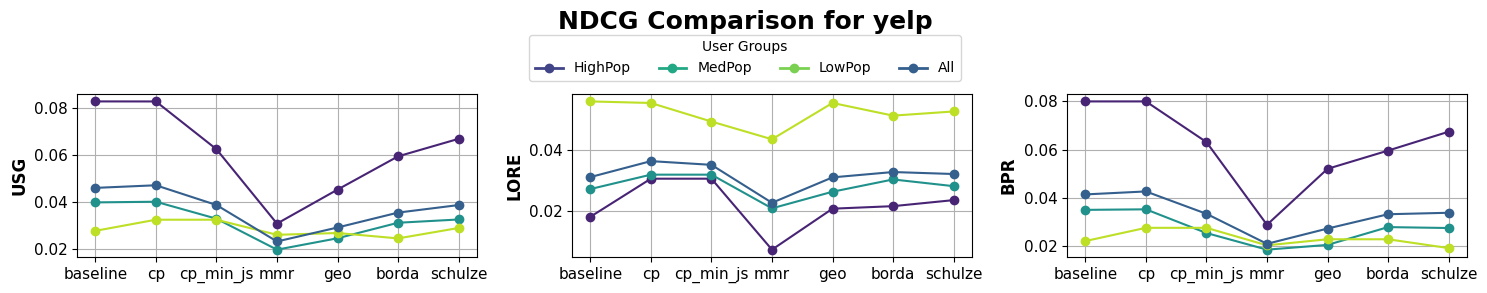

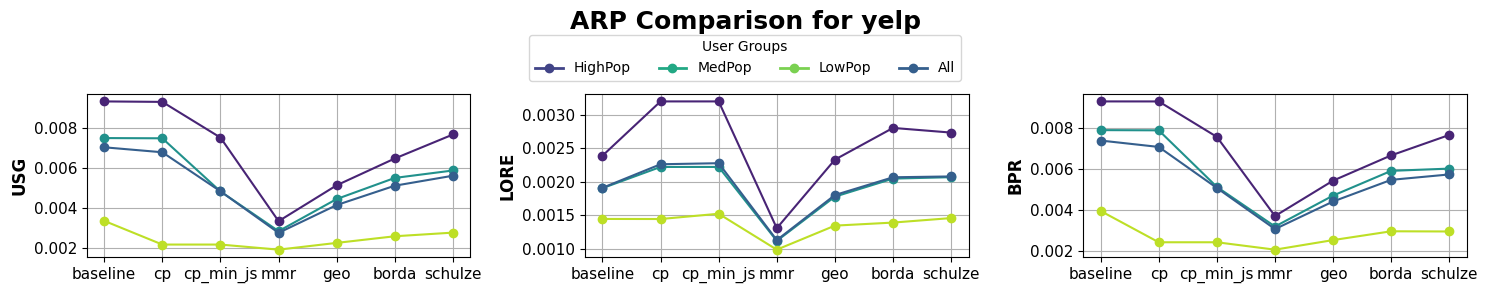

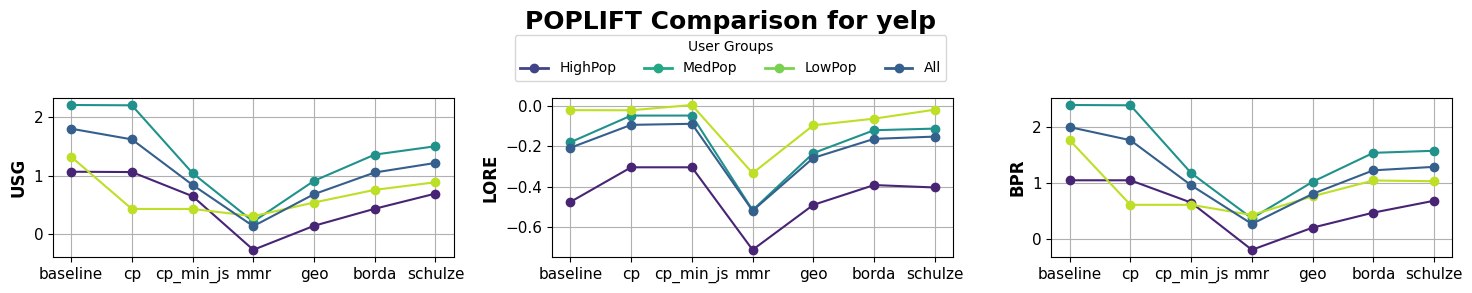

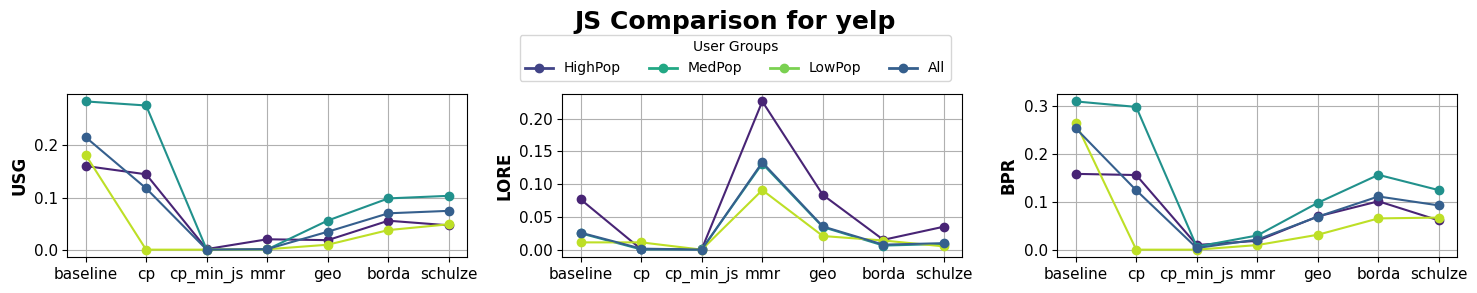

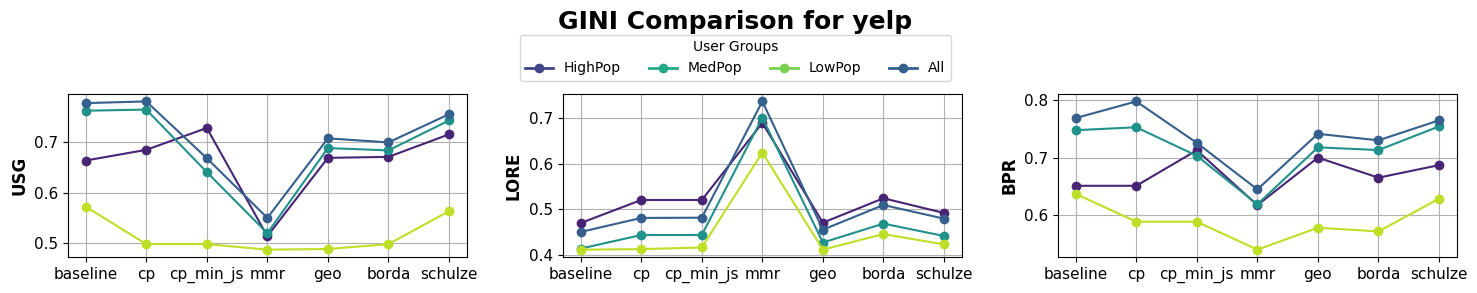

In [53]:

#plot_popularity_distributions(model_dirs, ground_truth_distr, dataset)
plot_metric(results, "ndcg", dataset)
plot_metric(results, "arp", dataset)
plot_metric(results, "poplift", dataset)
plot_metric(results, "js", dataset)
plot_metric(results, "gini", dataset)

In [61]:
results

{'USG': {'baseline': {'HighPop': {'ndcg': 0.08274389796100541,
    'arp': 0.009353113718411573,
    'poplift': 1.0661101807845044,
    'gini': 0.6637990196078432,
    'js': 0.16047827035107853},
   'LowPop': {'ndcg': 0.027562554224294177,
    'arp': 0.0033461943441636705,
    'poplift': 1.3229659339130047,
    'gini': 0.5723459560542314,
    'js': 0.18193390302370993},
   'MedPop': {'ndcg': 0.03969686301884306,
    'arp': 0.007509601885278757,
    'poplift': 2.2118355465873187,
    'gini': 0.7625695074802487,
    'js': 0.28415039546837517},
   'All': {'ndcg': 0.04587940824836573,
    'arp': 0.007045622743682222,
    'poplift': 1.8049165508918963,
    'gini': 0.7776548387096773,
    'js': 0.2157954988693291}},
  'cp': {'HighPop': {'ndcg': 0.08272587450074939,
    'arp': 0.009328971119133595,
    'poplift': 1.0605079991312367,
    'gini': 0.6849414414414413,
    'js': 0.14452472576171996},
   'LowPop': {'ndcg': 0.032308778965509564,
    'arp': 0.002154482551143207,
    'poplift': 0.42709